# Assignment 1

All exercises use a unified SF crime dataset spanning **2003–2025**, built by merging the SFPD historical (2003–2017) and modern (2018–2025) incident report datasets. Since the two datasets use different category schemas, we harmonized them into a single canonical naming convention. Key mapping decisions:

- `SEX OFFENSES, FORCIBLE` and `SEX OFFENSES, NON FORCIBLE` (historical) and `Rape` (recent) were all merged into **Sex Offense**.
- `WEAPON LAWS` (historical) and `Weapons Offence` / `Weapons Carrying Etc` (recent) were merged into **Weapons Offense**.
- `Drug Violation` (recent) was merged with `DRUG/NARCOTIC` (historical) into **Drug Offense**.
- `Motor Vehicle Theft?` (recent, a data entry artifact) was normalized to **Motor Vehicle Theft**.

Our **Personal Focus Crimes** are: Arson, Drug Offense, Robbery, Larceny Theft, Stolen Property, Suicide, Fraud , Vandalism, Weapons Offense.

---
## Assignment 1.1: Temporal Overview

> Using the combined dataset (2003–present), plot the total number of incidents **per year** for each Personal Focus Crime. Display at least the years 2003–2025. Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title. Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

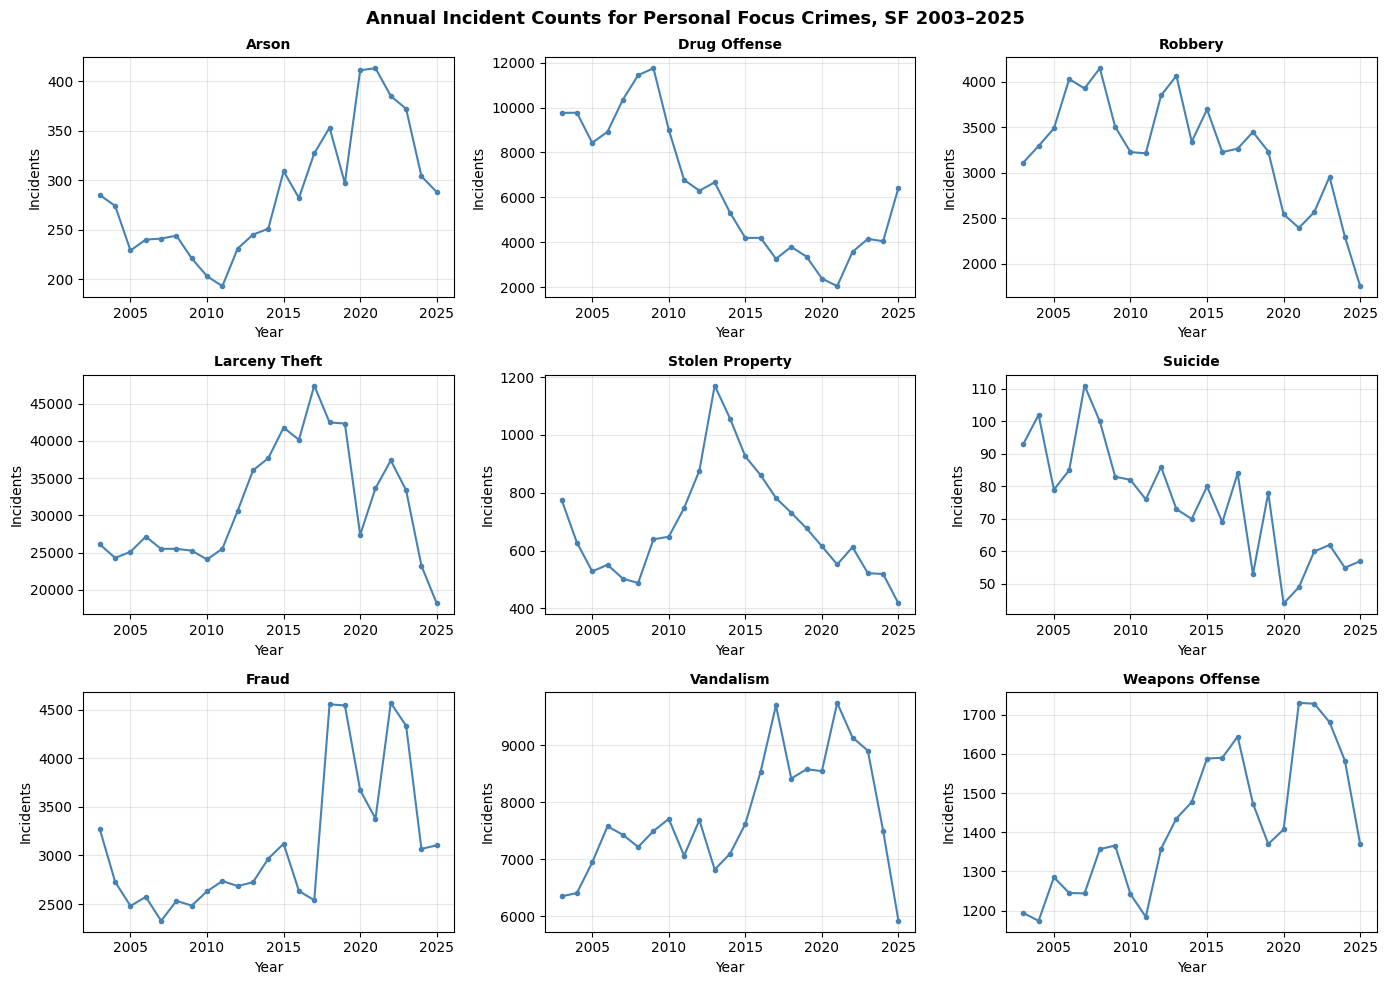

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('sf_crime_2003_2025.parquet')

focus_crimes = [
    'Arson', 'Drug Offense', 'Robbery', 'Larceny Theft',
    'Stolen Property', 'Suicide', 'Fraud', 'Vandalism', 'Weapons Offense'
]

# Count incidents per year per crime type
df_focus = df[df['Incident Category'].isin(focus_crimes)].copy()
yearly = (
    df_focus.groupby([df_focus['Incident Datetime'].dt.year, 'Incident Category'])
    .size()
    .unstack(fill_value=0)
)
yearly.index.name = 'Year'

# 3x3 grid — one subplot per crime
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, crime in zip(axes, focus_crimes):
    ax.plot(yearly.index, yearly[crime], marker='o', markersize=3, linewidth=1.5, color='steelblue')
    ax.set_title(crime, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Incidents')
    ax.grid(True, alpha=0.3)

fig.suptitle('Annual Incident Counts for Personal Focus Crimes, SF 2003–2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Notable features:**

**1. Drug Offense: long-term decline.** Drug Offense shows a sustained downward trend across the full period, falling from peaks in the mid-to-late 2000s and continuing lower through the 2010s. This mirrors SF's evolving enforcement priorities. The city progressively shifted toward diversion programmes and away from arresting individuals for personal drug possession, a direction reinforced statewide by Proposition 47 (2014), which reclassified many drug possession offences from felonies to misdemeanors.

**2. COVID-19 dip in 2020.** Nearly all crime types drop in 2020, with the sharpest declines in Robbery and Drug Offense. This aligns with SF's shelter-in-place order (March 2020), which reduced foot traffic and public activity e.g. crimes requiring a victim or a public setting were hit hardest.

**3. Fraud: post-COVID spike in 2022.** Fraud follows the general COVID dip in 2020–2021, but recovers far more sharply than other categories, surging to its highest levels around 2022. The most likely driver is the COVID-era fraud wave, where California's Employment Development Department (EDD) paid out an estimated $30B+ in fraudulent unemployment claims in 2020–2021. SF residents whose identities were used would typically file a police report, and that reporting lag means the bulk of cases hit the statistics in 2022 rather than 2020.

**Note on 2018 discontinuities.** Some categories show a spike around 2018, likely reflecting the merging of multiple crime categories into one at the dataset join point rather than a genuine real-world change.

---
## Assignment 1.2: Crime Profiles by Police District

> For each police district, compute the conditional crime profile: for each of your Personal Focus Crimes, calculate
> $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
> A value above 1 means the crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*. Visualize these ratios in a way that makes it easy to compare across both districts and crime types. Pick one district whose profile stands out and explain the pattern.

In [7]:
import pandas as pd

# Unique police districts
districts = sorted(df['Police District'].dropna().unique())
print(districts)

# City-wide P(crime) for each focus crime
n_total = len(df)
p_crime = {
    crime: (df['Incident Category'] == crime).sum() / n_total
    for crime in focus_crimes
}

# Compute r(crime, district) for every pair
rows = []
for district in districts:
    district_df = df[df['Police District'] == district]
    n_district = len(district_df)
    for crime in focus_crimes:
        p_crime_given_district = (district_df['Incident Category'] == crime).sum() / n_district
        ratio = p_crime_given_district / p_crime[crime]
        rows.append({'District': district, 'Crime': crime, 'Ratio': ratio})

ratios_df = pd.DataFrame(rows)
print(ratios_df)

['BAYVIEW', 'Bayview', 'CENTRAL', 'Central', 'INGLESIDE', 'Ingleside', 'MISSION', 'Mission', 'NORTHERN', 'Northern', 'Out of SF', 'PARK', 'Park', 'RICHMOND', 'Richmond', 'SOUTHERN', 'Southern', 'TARAVAL', 'TENDERLOIN', 'Taraval', 'Tenderloin']
       District            Crime     Ratio
0       BAYVIEW            Arson  2.198713
1       BAYVIEW     Drug Offense  0.971704
2       BAYVIEW          Robbery  1.208167
3       BAYVIEW    Larceny Theft  0.548805
4       BAYVIEW  Stolen Property  0.821849
..          ...              ...       ...
184  Tenderloin  Stolen Property  1.054059
185  Tenderloin          Suicide  0.656320
186  Tenderloin            Fraud  0.814143
187  Tenderloin        Vandalism  0.699067
188  Tenderloin  Weapons Offense  1.787888

[189 rows x 3 columns]


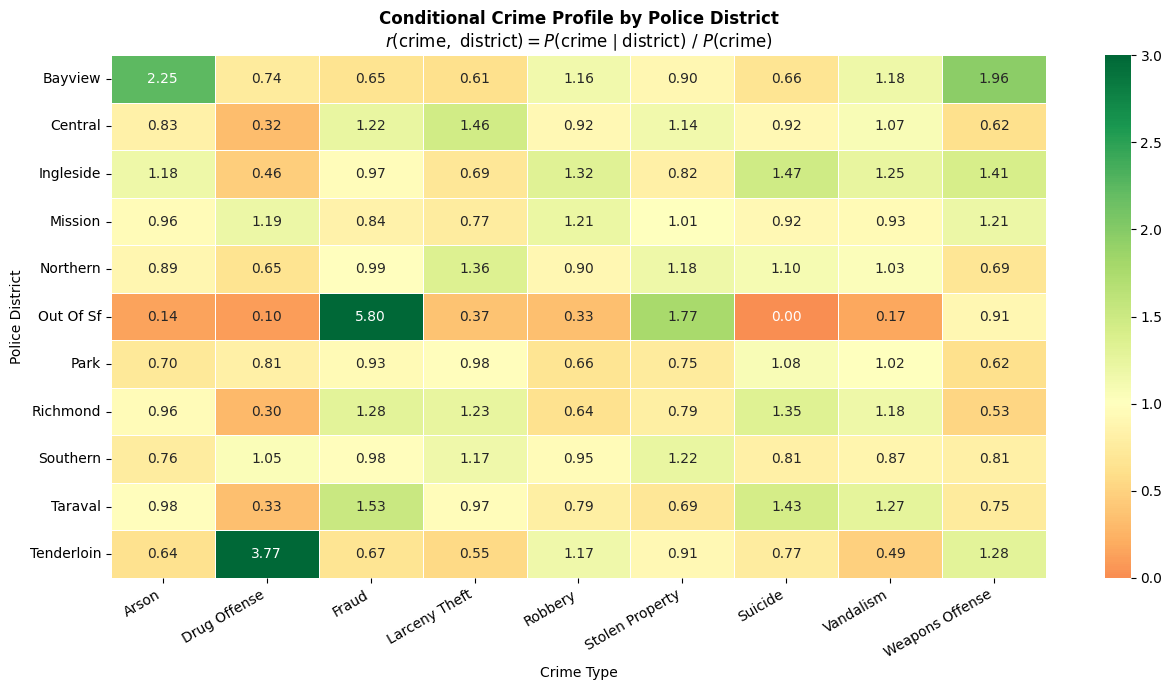

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = ratios_df.pivot(index='District', columns='Crime', values='Ratio')

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=1, vmin=0, vmax=3,
    linewidths=0.4, linecolor='white',
    ax=ax
)
ax.set_title(
    'Conditional Crime Profile by Police District\n'
    r'$r(\mathrm{crime},\ \mathrm{district}) = P(\mathrm{crime} \mid \mathrm{district})\ /\ P(\mathrm{crime})$',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Crime Type')
ax.set_ylabel('Police District')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Note on "Out of SF".** This row can be disregarded — it is not a real patrol district but a catch-all label for incidents that could not be assigned to any of the ten SFPD districts. Its extreme ratios (e.g. Fraud at 5.80) are artefacts of its unusual composition, not meaningful geographic patterns.

**Tenderloin** is the standout district. It is the smallest district in SF by area, yet it shows the highest Drug Offense ratio in the entire matrix at **3.77×** the city-wide average — meaning a randomly chosen incident in Tenderloin is nearly four times more likely to be a drug offence than one chosen from the city at large. This is consistent with Tenderloin's well-documented role as the centre of SF's open drug market, with high foot traffic, a dense population of vulnerable residents, and historically concentrated enforcement activity.

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- choose which crime to display on the map ---
map_crime = 'Larceny Theft'

# Load SFPD district boundaries from local file
gdf = gpd.read_file('Current_Police_Districts_20260224.geojson')

# Normalise district name to Title Case to match our ratios_df
gdf['district'] = gdf['district'].str.title()

# Merge ratios for the chosen crime onto the geodataframe
crime_ratios = ratios_df[ratios_df['Crime'] == map_crime].set_index('District')['Ratio']
gdf['ratio'] = gdf['district'].map(crime_ratios)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    column='ratio',
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=3,
    edgecolor='white', linewidth=0.8,
    legend=False,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

# Label each district with its name and ratio
for _, row in gdf.iterrows():
    if row['ratio'] is not None:
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['district']}\n{row['ratio']:.2f}",
            xy=(centroid.x, centroid.y),
            ha='center', va='center', fontsize=7.5, fontweight='bold'
        )

# Colorbar
sm = ScalarMappable(cmap='RdYlGn', norm=Normalize(vmin=0, vmax=3))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('r(crime, district)', fontsize=10)
cbar.ax.axhline(1, color='black', linewidth=1.5, linestyle='--')

ax.set_title(
    f'Crime Profile Ratio by District — {map_crime}\n'
    r'$r = 1$ (dashed) = city-wide average',
    fontsize=11, fontweight='bold'
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

**Larceny Theft** is the most common crime in the dataset overall, and the map shows it is heavily concentrated in Central and Northern districts — the commercial and tourist corridors of downtown SF. Tenderloin, despite its reputation and central location, sits at just **0.55×** the city average for Larceny Theft. This is somewhat counter-intuitive but reflects the nature of the neighbourhood: Larceny Theft is driven by shoplifting and property crime in high-footfall retail areas, whereas Tenderloin's crime profile is dominated by drug activity rather than opportunistic theft.

---
## Assignment 1.3: Visualizing Distributions

### Part A — Jitter plot

> Pick one of your Personal Focus Crimes and a suitable time interval. Create a jitter plot of the incident times during a single hour: let time run along the $x$-axis and add vertical jitter. What does the jitter plot reveal about how times are recorded in the dataset?

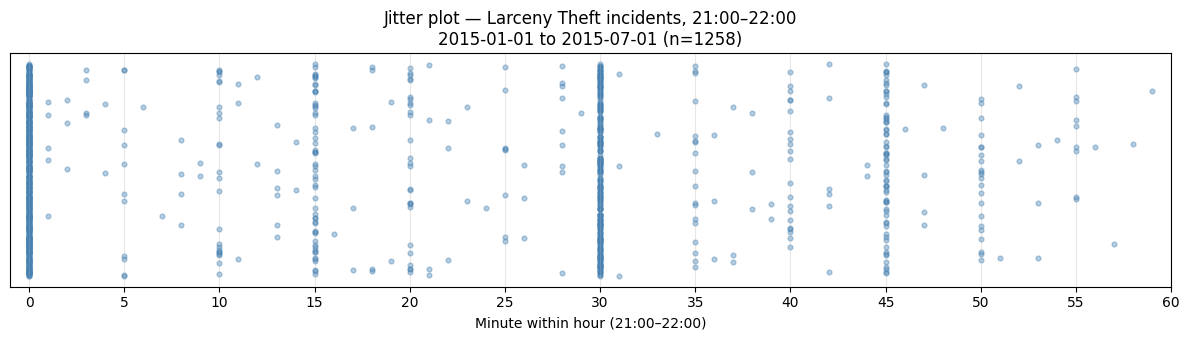

In [31]:
import numpy as np
import matplotlib.pyplot as plt

crime  = 'Larceny Theft'
start  = pd.Timestamp('2015-01-01')
end    = pd.Timestamp('2015-07-01')
hour   = 21

mask = (
    (df['Incident Category'] == crime) &
    (df['Incident Datetime'] >= start) &
    (df['Incident Datetime'] < end) &
    (df['Incident Datetime'].dt.hour == hour)
)
subset = df[mask].copy()
subset['minute'] = subset['Incident Datetime'].dt.minute + subset['Incident Datetime'].dt.second / 60

np.random.seed(42)
subset['jitter'] = np.random.uniform(-0.4, 0.4, size=len(subset))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.scatter(subset['minute'], subset['jitter'], alpha=0.4, s=12, color='steelblue')
ax.set_xlabel('Minute within hour (21:00–22:00)')
ax.set_yticks([])
ax.set_xlim(-1, 60)
ax.set_xticks(range(0, 61, 5))
ax.set_title(
    f'Jitter plot — {crime} incidents, {hour:02d}:00–{hour+1:02d}:00\n'
    f'{start.date()} to {end.date()} (n={len(subset)})'
)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

The jitter plot reveals an obvious pattern: incident times are heavily concentrated at **minute 0 and minute 30**, with secondary clustering at 5-minute intervals (10, 15, 20, 45), and almost no incidents recorded in between. Two factors likely contribute to this.

First, there is a reporting precision effect: when a victim calls in a theft, they rarely know the exact time — they report something like *"it was around 9:30"*, and the officer logs it as exactly 21:30. This alone would explain the dominance of round numbers.

Second, for planned or patrol-detected incidents, officers may themselves default to noting the time at the nearest convenient mark when filling out the report after the fact, further compressing the distribution toward multiples of 5 or 15 minutes.

Either way, the strong clustering very likely reflects **human rounding behaviour rather than genuine precision** in when crimes occur, suggesting that recorded incident times should not be treated as exact measurements.

### Part B — Probability plot

> Create a probability plot (QQ plot) for the latitude distribution of two crime types using `scipy.stats.probplot`. What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that tell you about the geography of crime in SF?

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

crimes_qq = ['Drug Offense', 'Larceny Theft']

# Valid SF latitude range — filters out bad placeholder coordinates (e.g. Y=90)
LAT_MIN, LAT_MAX = 37.60, 37.85

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, crime in zip(axes, crimes_qq):
    lats = df[
        (df['Incident Category'] == crime) &
        (df['Latitude'] >= LAT_MIN) &
        (df['Latitude'] <= LAT_MAX)
    ]['Latitude'].dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(lats, dist='norm')
    ax.scatter(osm, osr, s=1, alpha=0.2, color='steelblue', label='Data')
    ax.plot(osm, slope * osm + intercept, color='red', linewidth=1.5, label='Normal fit')
    ax.set_title(f'{crime}  (n={len(lats):,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Theoretical quantiles (Normal)')
    ax.set_ylabel('Sample quantiles (Latitude)')
    ax.legend(markerscale=5, fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('QQ plots — Latitude distribution vs. Normal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The reference distribution is the **standard normal**. If the data points fell exactly on the red line, it would mean that incident latitudes are normally distributed, i.e. crimes spread smoothly across the city with most activity in a central band and a gradual taper toward the northern and southern edges.

Neither crime follows this. Both plots roughly follow an **S-curve**, indicating that the latitude distribution deviates systematically from normal and that incidents are not spread evenly across the city. The **stepped, flat sections** visible in both plots reveal discrete hotspots where a large number of incidents pile up at nearly identical latitudes, consistent with heavy concentration in specific neighbourhoods. This effect is more pronounced in Drug Offense, reflecting its strong concentration in areas like the Tenderloin. Larceny Theft follows the normal line more closely through the middle, reflecting its broader spread across the commercial corridors of the city, though it still deviates noticeably in both tails.

### Part C — Box plots of time-of-day

> For each Personal Focus Crime, extract the time-of-day of every incident and create side-by-side box plots. What patterns do you see? Are there crimes that happen mostly at night or during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well?

Rather than a standard box plot, we use a **violin plot**, which shows the full density of the distribution at every hour rather than just the quartiles. This is more informative here because it reveals whether crimes are unimodal (one clear peak) or bimodal (two distinct peaks), and makes the midnight wrap-around problem visible as a shape rather than just a misleading median. The time axis is shifted by 6 hours so that 06:00 sits at the boundary, preventing late-night crimes from being split across 23:00 and 00:00.

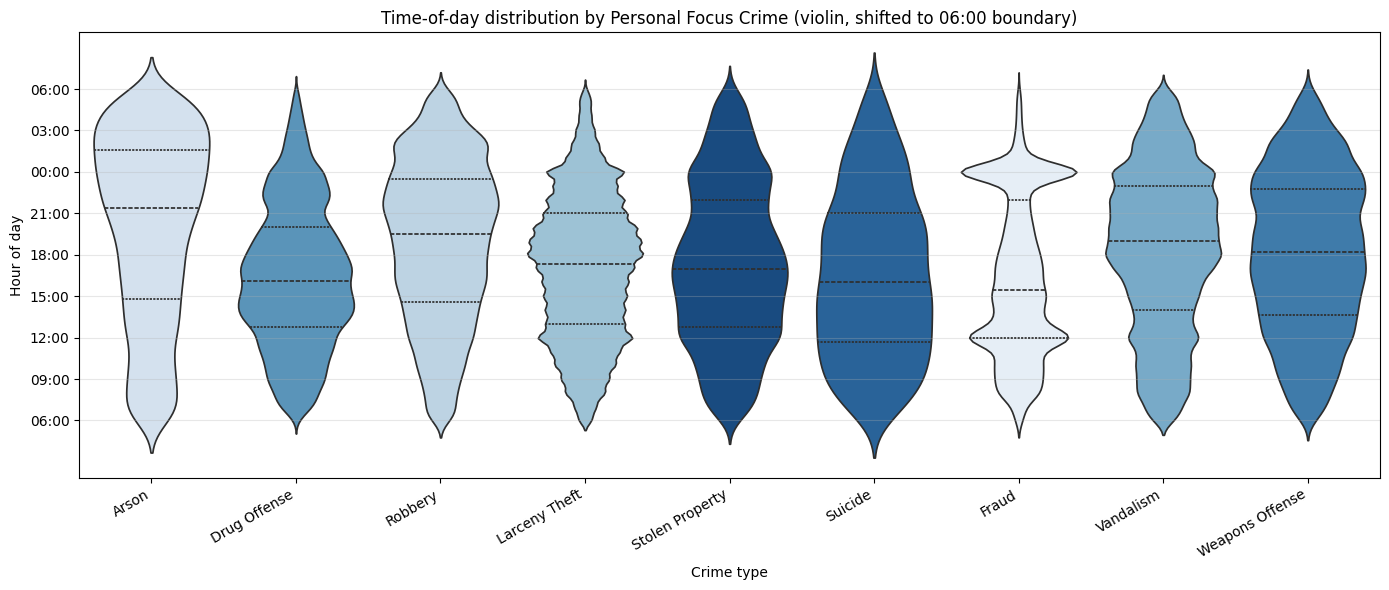

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

df_focus = df[df['Incident Category'].isin(focus_crimes)].copy()
df_focus['time_of_day'] = (
    df_focus['Incident Datetime'].dt.hour +
    df_focus['Incident Datetime'].dt.minute / 60
)
df_focus['time_shifted'] = (df_focus['time_of_day'] - 6) % 24

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=df_focus,
    x='Incident Category',
    y='time_shifted',
    order=focus_crimes,
    inner='quartile',
    palette='Blues',
    hue='Incident Category',
    ax=ax
)

ax.set_ylabel('Hour of day')
ax.set_xlabel('Crime type')
ax.set_yticks(range(0, 25, 3))
ax.set_yticklabels([f'{(h + 6) % 24:02d}:00' for h in range(0, 25, 3)])
ax.set_title('Time-of-day distribution by Personal Focus Crime (violin, shifted to 06:00 boundary)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The violin plot reveals clear differences in when crimes occur. **Fraud** has the narrowest violin by far, with its density tightly concentrated between 09:00 and 15:00 and almost nothing outside those hours, confirming it as a strictly business-hours crime driven by phone scams, identity fraud, and financial deception when victims are reachable.

**Arson** is the opposite: it has the widest violin of all categories, with its bulk pushed toward the evening and early morning hours. This makes intuitive sense, as fires set deliberately are more likely at night when detection is harder.

**Drug Offense** and **Robbery** both show a bimodal shape with two distinct density bulges, suggesting activity at two separate times of day rather than one smooth peak. **Larceny Theft** has a notably lumpy, stepped shape, which is likely the minute-rounding artefact from Part A showing up at scale across millions of incidents.

**Suicide** has an unusual thin spike reaching toward the early morning hours, indicating a small but consistent concentration of incidents in the very early hours of the day, distinct from the general daytime pattern of most other crimes.

---
## Assignment 1.4: Spatial Power Law

> Using your most common Personal Focus Crime, divide SF into a grid of approximately 100m × 100m cells and count incidents per cell. Plot the distribution of cell counts N(k) (number of cells with exactly k incidents) on both linear and log-log axes. Does the crime follow a power-law spatial distribution, and what does that imply for how we interpret neighbourhood-level crime statistics?

Our most common Personal Focus Crime by total incident count is **Larceny Theft**.

Total Larceny Theft incidents after filtering: 719,869
Grid size: 133 × 149 = 19,817 total cells
Land cells: 11,202  |  Water/excluded cells: 8,615
Max incidents in a single land cell: 16,742
Empty land cells: 2,571  (23.0%)


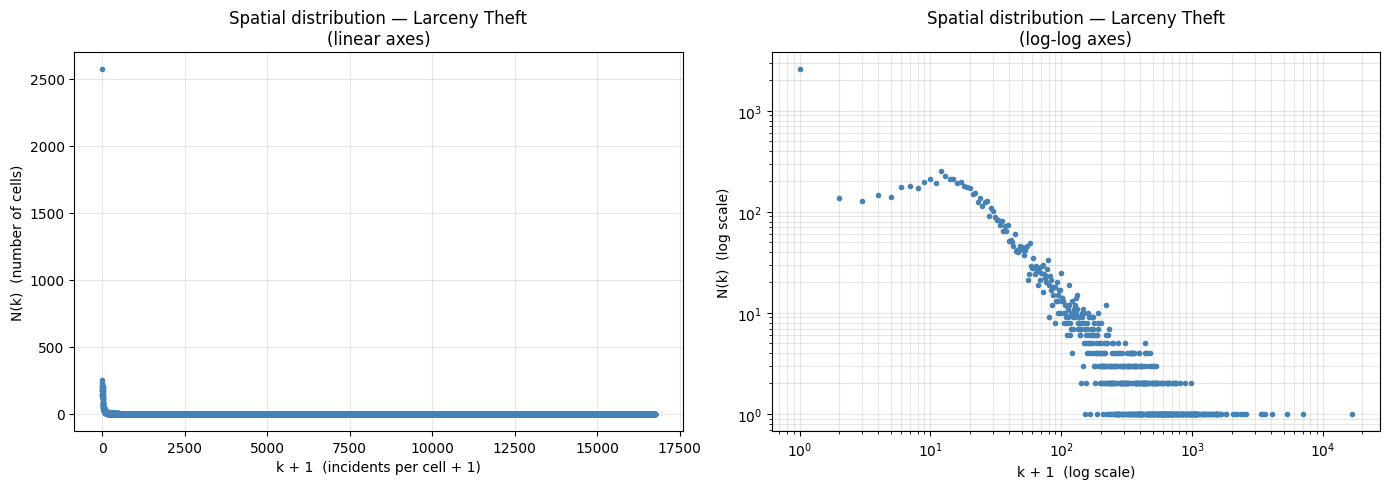

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

crime = 'Larceny Theft'

# Filter to valid SF coordinates
df_crime = df[
    (df['Incident Category'] == crime) &
    (df['Latitude']  >= 37.70) & (df['Latitude']  <= 37.82) &
    (df['Longitude'] >= -122.52) & (df['Longitude'] <= -122.35)
].copy()

# ~100m grid cells
lat_bins = np.arange(37.70,   37.82,  0.0009)
lon_bins = np.arange(-122.52, -122.35, 0.00114)

counts, _, _ = np.histogram2d(
    df_crime['Latitude'], df_crime['Longitude'],
    bins=[lat_bins, lon_bins]
)

# Build SF land boundary from police district polygons
gdf_sf = gpd.read_file('Current_Police_Districts_20260224.geojson')
sf_boundary = gdf_sf.geometry.union_all()

# Check which cell centroids fall on land
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

points = gpd.GeoSeries(
    [Point(x, y) for x, y in zip(lon_grid.flatten(), lat_grid.flatten())]
)
land_mask = points.within(sf_boundary).values.reshape(counts.shape)

# Only keep land cells
counts_land = counts[land_mask].astype(int)

# Tally N(k) over land cells only
k_max = int(counts_land.max())
k_values = np.arange(0, k_max + 1)
N_k = np.array([(counts_land == k).sum() for k in k_values])

# --- Linear plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values + 1, N_k, 'o', markersize=3, color='steelblue')
axes[0].set_xlabel('k + 1  (incidents per cell + 1)')
axes[0].set_ylabel('N(k)  (number of cells)')
axes[0].set_title(f'Spatial distribution — {crime}\n(linear axes)')
axes[0].grid(True, alpha=0.3)

# --- Log-log plot ---
mask = N_k > 0
axes[1].loglog(k_values[mask] + 1, N_k[mask], 'o', markersize=3, color='steelblue')
axes[1].set_xlabel('k + 1  (log scale)')
axes[1].set_ylabel('N(k)  (log scale)')
axes[1].set_title(f'Spatial distribution — {crime}\n(log-log axes)')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

To avoid inflating the count of empty cells with water and bay area grid squares, we use the SF police district GeoJSON (already available from Assignment 1.2) to build a land boundary for the city. Only grid cell centroids that fall within this boundary are included in the analysis.

**Linear axes:** The linear plot is almost unreadable. Even after excluding water and bay area cells, roughly 2,600 land cells remain empty, creating a dominant spike at k=0 that compresses everything else. This alone tells us that Larceny Theft is far from evenly distributed across the city's land area.

**Log-log axes:** The log-log plot is far more informative. The general pattern shows a steep downward trend: a large number of cells have very few incidents, and only a small number of cells have many. From around k+1 = 100 onwards, the decay follows a roughly straight line on the log-log axes, which is the characteristic signature of a **power law distribution**. The fit is not perfect, particularly at low k values where there is a bump, but the heavy tail behaviour is clear. Most strikingly, a single cell reaches 16,742 incidents over the full period, almost certainly corresponding to a specific block in the Union Square area where Larceny Theft is heavily concentrated.

**Implications:** If crime follows a power-law spatial distribution, the "average block" statistic is essentially meaningless. The vast majority of blocks have near-zero incidents, while a tiny number of extreme hotspots account for a disproportionate share of all crime. Policies or comparisons based on city-wide or neighbourhood averages risk masking this concentration entirely, and any meaningful intervention would need to target the small number of specific locations driving the numbers.

---
## Assignment 1.5: Regression and Correlation

> For each selected crime type, compute the total number of incidents for each of the 168 hours of the week (Monday 00:00 through Sunday 23:00). Create a pairwise scatterplot matrix where each panel plots two crimes against each other across the 168 hours. Fit a regression line using the closed-form equations and display R² on each panel. Which pair is most correlated? Which is least correlated?

We use all 9 Personal Focus Crimes to get the full picture.

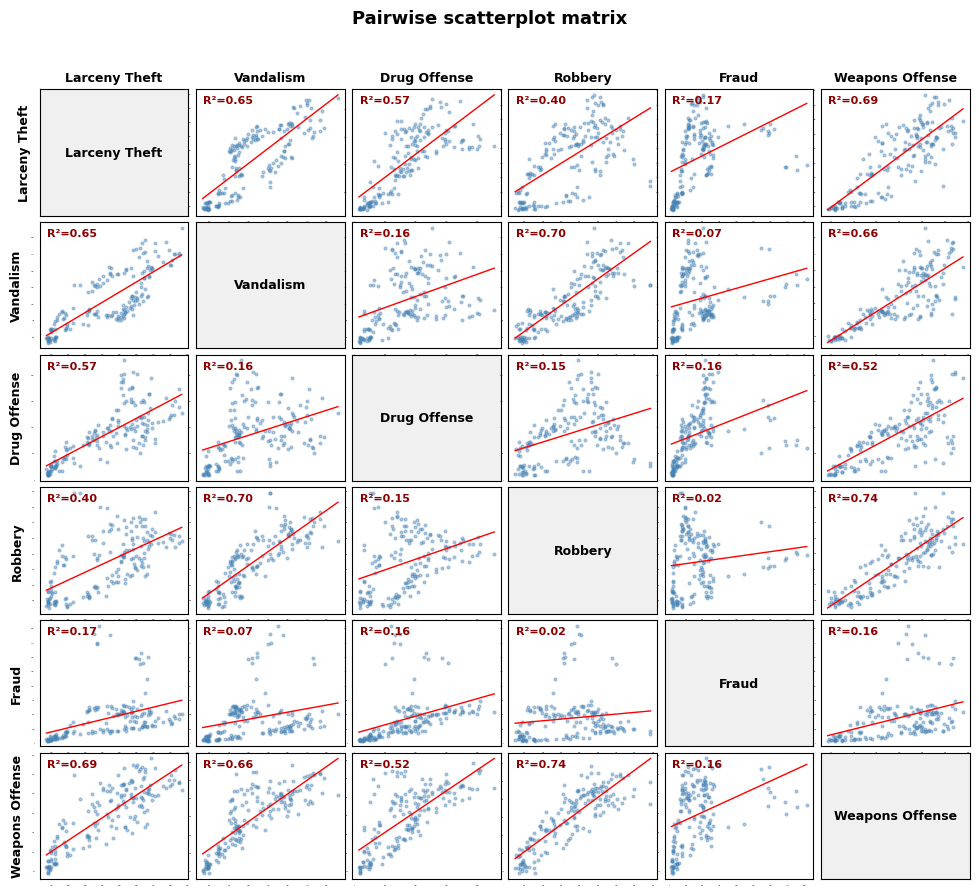

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- Select the 6 most common focus crimes ---
crime_totals = {crime: (df['Incident Category'] == crime).sum() for crime in focus_crimes}
top6 = sorted(crime_totals, key=crime_totals.get, reverse=True)[:6]

# --- 168-hour weekly profile ---
weekly = {}
for crime in top6:
    sub = df[df['Incident Category'] == crime].copy()
    sub['hour_of_week'] = (
        sub['Incident Datetime'].dt.dayofweek * 24 +
        sub['Incident Datetime'].dt.hour
    )
    counts = sub.groupby('hour_of_week').size().reindex(range(168), fill_value=0)
    weekly[crime] = counts.values.astype(float)

# --- Closed-form linear regression ---
def linreg(x, y):
    N = len(x)
    xm, ym = x.mean(), y.mean()
    a = (np.dot(x, y) - N * xm * ym) / (np.dot(x, x) - N * xm**2)
    b = ym - a * xm
    return a, b

def r_squared(x, y, a, b):
    ss_res = np.sum((y - (a * x + b))**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot

# --- Scatterplot matrix ---
n = len(top6)
fig, axes = plt.subplots(n, n, figsize=(12, 10))
fig.subplots_adjust(hspace=0.05, wspace=0.05, top=0.90)

for i, crime_y in enumerate(top6):
    for j, crime_x in enumerate(top6):
        ax = axes[i, j]
        x = weekly[crime_x]
        y = weekly[crime_y]

        if i == j:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, crime_y, ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, fontweight='bold',
                    wrap=True, multialignment='center')
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.scatter(x, y, s=4, alpha=0.4, color='steelblue')
            a, b = linreg(x, y)
            r2 = r_squared(x, y, a, b)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, a * x_line + b, color='red', linewidth=1)
            ax.text(0.05, 0.95, f'R²={r2:.2f}', transform=ax.transAxes,
                    fontsize=8, va='top', color='darkred', fontweight='bold')
            ax.tick_params(labelsize=0, length=0)

        # Column labels on top row
        if i == 0:
            ax.set_title(crime_x, fontsize=9, fontweight='bold', pad=6)
        # Row labels on left column
        if j == 0:
            ax.set_ylabel(crime_y, fontsize=9, fontweight='bold', labelpad=6)

fig.suptitle(
    'Pairwise scatterplot matrix',
    fontsize=13, fontweight='bold'
)
plt.show()

**Most correlated: Robbery and Weapons Offense (R²=0.74).** This is the strongest pair in the matrix and matches intuition well. Robberies are frequently carried out at gunpoint or with weapons, meaning the two crime types are often directly linked to the same incidents and are therefore naturally correlated. Larceny Theft and Weapons Offense (R²=0.69) and Vandalism and Robbery (R²=0.70) are close behind, and together Larceny Theft, Vandalism, Robbery, and Weapons Offense form a cluster of street crimes that all broadly share the same weekly rhythm.

**Least correlated: Fraud vs almost everything.** Fraud scores R²=0.07 against Vandalism and R²=0.02 against Robbery, essentially showing no shared weekly pattern at all. This is exactly what we would expect given the findings from Assignment 1.3C: Fraud is a strictly business-hours crime concentrated between 09:00 and 15:00 on weekdays, while the rest of the crimes in this cluster are evening and night-time street crimes. The two rhythms are completely out of phase, so knowing how busy a given hour is for robbery tells you almost nothing about how busy it will be for fraud.

Drug Offense sits somewhere in between, correlating moderately with Larceny Theft (R²=0.57) but poorly with both Vandalism (R²=0.16) and Robbery (R²=0.15), reflecting its more complex temporal pattern with multiple daily peaks as seen in the violin plot - tells us something about how drug offences can happen at any point in the day.

# Contributions for Assignment 1 - group 88

This assignment has been done solely by me (by choice) - Marcus Lilleør Christoffersen - s224750